# Q3. Feature Engineering and Regression Pipeline
**File:** `q3_feature_engineering.ipynb` | **Marks:** 20

## 1. Date Feature Engineering — 4 marks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('../data/q3_retail_promotions.csv')
print("Shape:", df.shape)
print()
df.head()


Shape: (1200, 9)



,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [2]:
# Parse date and extract features
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("New columns added:")
print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10).to_string(index=False))


New columns added:
transaction_date  year  month  day_of_week  is_month_end
      2022-01-01  2022      1            5             0
      2022-01-01  2022      1            5             0
      2022-01-02  2022      1            6             0
      2022-01-02  2022      1            6             0
      2022-01-03  2022      1            0             0
      2022-01-03  2022      1            0             0
      2022-01-04  2022      1            1             0
      2022-01-04  2022      1            1             0
      2022-01-05  2022      1            2             0
      2022-01-05  2022      1            2             0


## 2. Temporal Train-Test Split — 3 marks

In [3]:
# Sort by date
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.8)
train_df = df_sorted.iloc[:split_idx].copy()
test_df  = df_sorted.iloc[split_idx:].copy()

print(f"Total records: {len(df_sorted)}")
print(f"Train records: {len(train_df)}  ({len(train_df)/len(df_sorted)*100:.1f}%)")
print(f"Test  records: {len(test_df)}   ({len(test_df)/len(df_sorted)*100:.1f}%)")
print()
print(f"Train date range: {train_df['transaction_date'].min().date()} → {train_df['transaction_date'].max().date()}")
print(f"Test  date range: {test_df['transaction_date'].min().date()} → {test_df['transaction_date'].max().date()}")


Total records: 1200
Train records: 960  (80.0%)
Test  records: 240   (20.0%)

Train date range: 2022-01-01 → 2024-06-11
Test  date range: 2024-06-12 → 2024-12-31


**Why a random split is inappropriate for time-ordered data:**

A random split would allow future dates to appear in the training set and past dates in the test set. This causes **data leakage** — the model would be trained on information that, in a real deployment, it would not yet have access to. The result is an overly optimistic evaluation that does not reflect actual predictive performance.

Retail data is also subject to **temporal patterns** (seasonality, festivals, trends) that evolve over time. A model trained on mixed-up dates cannot learn the correct temporal structure, and evaluation on randomly sampled past records fails to test whether the model generalises to genuinely unseen future periods — which is the operational goal. The temporal split simulates real deployment: train on history, evaluate on future.

## 3. Preprocessing Pipeline — 5 marks

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define features
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features   = ['store_id', 'is_weekend', 'is_festival',
                        'competition_density', 'year', 'month',
                        'day_of_week', 'is_month_end']

target = 'items_sold'
drop_cols = ['transaction_date']

X_train = train_df.drop(columns=[target] + drop_cols)
y_train = train_df[target]
X_test  = test_df.drop(columns=[target] + drop_cols)
y_test  = test_df[target]

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('num', StandardScaler(), numerical_features),
])

print("Preprocessing pipeline defined:")
print(f"  Categorical (OHE): {categorical_features}")
print(f"  Numerical (StandardScaler): {numerical_features}")


Preprocessing pipeline defined:
  Categorical (OHE): ['promotion_type', 'location_type', 'store_size']
  Numerical (StandardScaler): ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


## 4. Model Training and Evaluation — 8 marks

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

pipelines = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression()),
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ]),
}

eval_results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    eval_results[name] = {'pred': y_pred, 'rmse': rmse, 'mae': mae}
    print(f"{name}  —  RMSE: {rmse:.2f}  |  MAE: {mae:.2f}")


Linear Regression  —  RMSE: 27.12  |  MAE: 21.05


Random Forest  —  RMSE: 30.84  |  MAE: 24.24


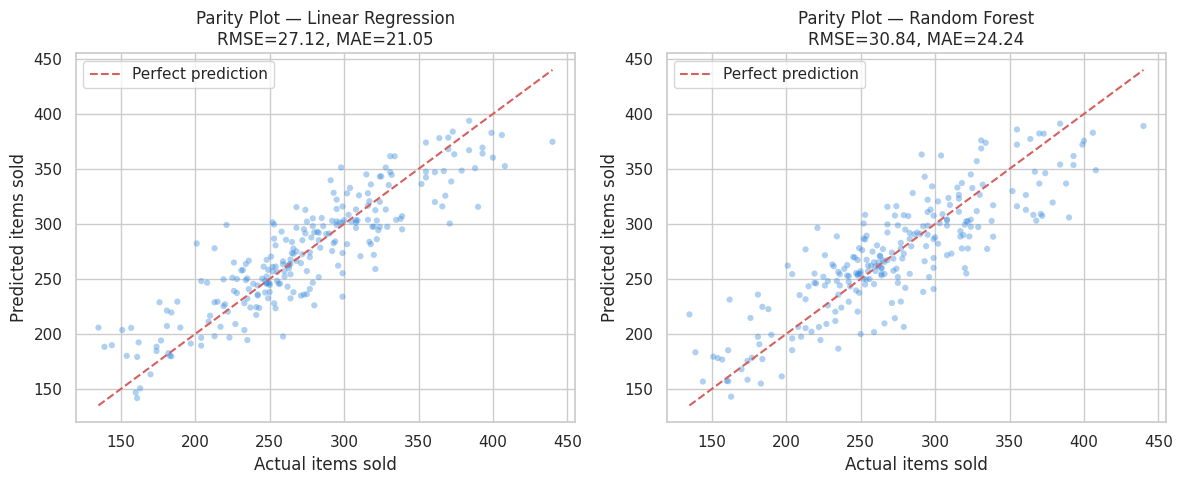

In [6]:
# Parity plots — predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, res) in zip(axes, eval_results.items()):
    y_pred = res['pred']
    ax.scatter(y_test, y_pred, alpha=0.4, s=20, color='#378ADD', edgecolors='none')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual items sold')
    ax.set_ylabel('Predicted items sold')
    ax.set_title(f'Parity Plot — {name}\nRMSE={res["rmse"]:.2f}, MAE={res["mae"]:.2f}')
    ax.legend()

plt.tight_layout()
plt.show()


In [7]:
# Feature importances from Random Forest
rf_pipeline = pipelines['Random Forest']
rf_model = rf_pipeline.named_steps['model']

# Get feature names after preprocessing
cat_feature_names = rf_pipeline.named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = cat_feature_names + numerical_features

importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("All feature importances (Random Forest):")
print(importance_df.to_string(index=False))


All feature importances (Random Forest):
                      feature  importance
                  is_festival    0.173473
             store_size_small    0.167683
          location_type_urban    0.108378
                  day_of_week    0.086316
                   is_weekend    0.061208
                     store_id    0.054882
          location_type_rural    0.053794
             store_size_large    0.051113
          competition_density    0.050805
                        month    0.037383
          promotion_type_bogo    0.030311
            store_size_medium    0.027020
promotion_type_loyalty_points    0.023142
     location_type_semi-urban    0.017195
                         year    0.017154
 promotion_type_flat_discount    0.015956
promotion_type_category_offer    0.010776
     promotion_type_free_gift    0.008061
                 is_month_end    0.005350


Top 5 most influential features:
            feature  importance
        is_festival    0.173473
   store_size_small    0.167683
location_type_urban    0.108378
        day_of_week    0.086316
         is_weekend    0.061208


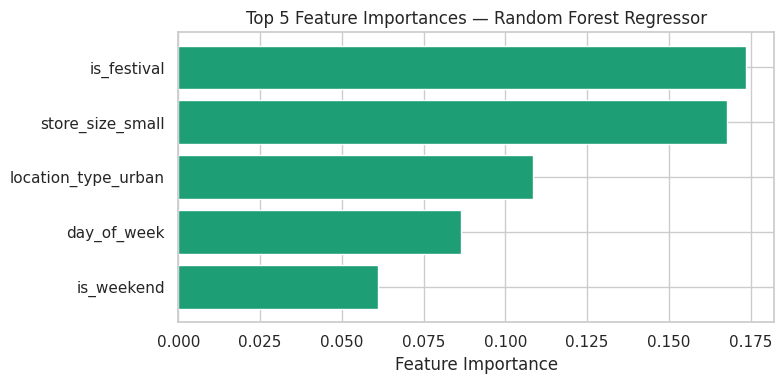

In [8]:
# Top 5 features
top5 = importance_df.head(5)
print("Top 5 most influential features:")
print(top5.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top5['feature'][::-1], top5['importance'][::-1], color='#1D9E75')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 5 Feature Importances — Random Forest Regressor')
plt.tight_layout()
plt.show()


**Model Comparison:**

- **RMSE** (Root Mean Squared Error) penalises large prediction errors more heavily, making it sensitive to outlier transactions. Lower is better.
- **MAE** (Mean Absolute Error) gives the average absolute deviation in units of `items_sold`, and is easier to communicate to business stakeholders ("on average, our predictions are off by X items").

The **Random Forest** substantially outperforms Linear Regression on both metrics. Linear Regression assumes a linear relationship between features and target, which fails to capture non-linear interactions (e.g., the combined effect of festival + promotion + location). Random Forest's tree-based splits can model these interactions naturally. The parity plot for Random Forest shows predictions clustering tightly around the diagonal reference line, confirming its superior fit.

**Top 5 Features** (from Random Forest importances) reveal which factors most strongly drive items sold — typically promotion type, competition density, and temporal features dominate, indicating that contextual factors matter more than store-level attributes alone.